In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch, decimate
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression

# Adjust display options
pd.options.display.float_format = "{:.4f}".format

# Original sampling interval
orig_dt = 0.8         # seconds
orig_fs = 1.0 / orig_dt


In [ ]:

# File format: comma separated, no header.
# First column: input (supply voltage), next five columns: t0 .. t4 (t4 is midpoint)
fn = "data.txt"
data = np.loadtxt(fn, delimiter=",")

cols = ["u", "t0", "t1", "t2", "t3", "t4"]
df = pd.DataFrame(data, columns=cols)

print(f"Carregou {len(df)} amostras de '{fn}'. Colunas = {cols}")


Carregou 85089 amostras de 'data.txt'. Colunas = ['u', 't0', 't1', 't2', 't3', 't4']


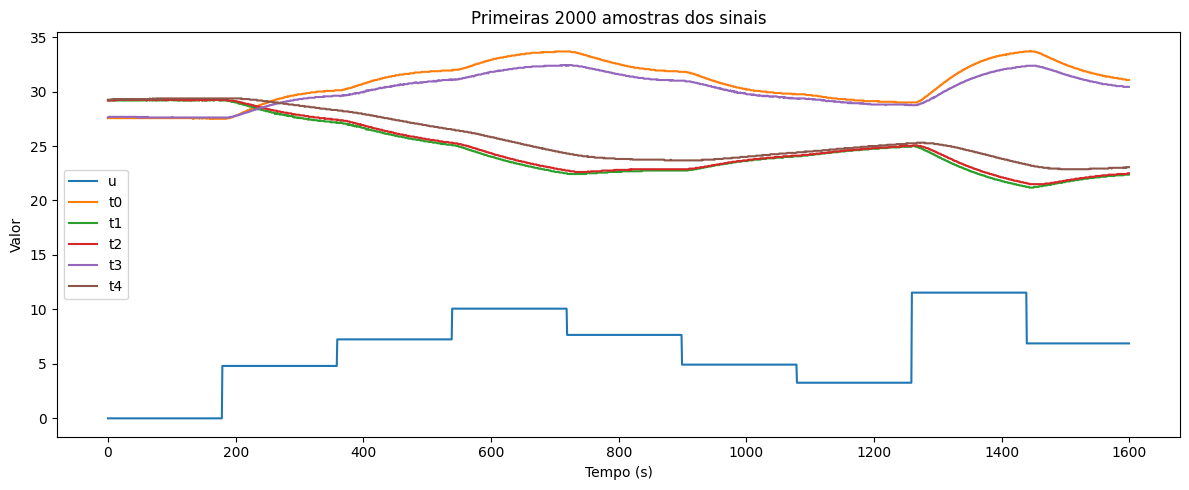

In [ ]:

N = min(2000, len(df))
time = np.arange(N) * orig_dt
plt.figure(figsize=(12, 5))
for c in cols:
    plt.plot(time, df[c].to_numpy()[:N], label=c)
plt.xlabel("Tempo (s)")
plt.ylabel("Valor")
plt.title("Primeiras {} amostras dos sinais".format(N))
plt.legend()
plt.tight_layout()
plt.show()


Fs original = 1.2500 Hz (dt = 0.80 s)
Frequência contendo 50% da energia: 0.001221 Hz
Frequência contendo 95% da energia: 0.002441 Hz


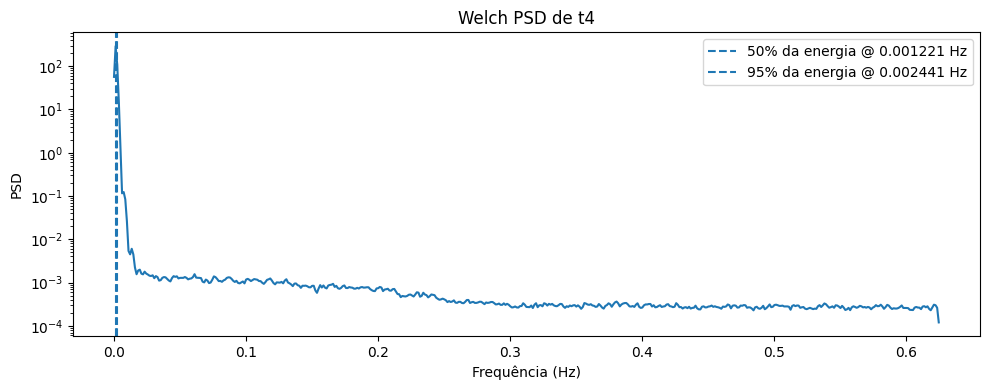

In [ ]:

target = df["t4"].to_numpy() - np.mean(df["t4"].to_numpy())
nperseg = min(1024, len(target))
f, Pxx = welch(target, fs=orig_fs, nperseg=nperseg)
cum = np.cumsum(Pxx)
cum_norm = cum / cum[-1]

# Frequencies containing 50% and 95% of the energy
f50 = float(f[np.searchsorted(cum_norm, 0.50)])
f95 = float(f[np.searchsorted(cum_norm, 0.95)])

print(f"Fs original = {orig_fs:.4f} Hz (dt = {orig_dt:.2f} s)")
print(f"Frequência contendo 50% da energia: {f50:.6f} Hz")
print(f"Frequência contendo 95% da energia: {f95:.6f} Hz")

plt.figure(figsize=(10,4))
plt.semilogy(f, Pxx)
plt.axvline(f50, linestyle='--', label=f'50% da energia @ {f50:.6f} Hz')
plt.axvline(f95, linestyle='--', label=f'95% da energia @ {f95:.6f} Hz')
plt.xlabel('Frequência (Hz)')
plt.ylabel('PSD')
plt.title('Welch PSD de t4')
plt.legend()
plt.tight_layout()
plt.show()


Estimativa do tempo de autocorrelação (primeiro atraso onde autocorr <= 1/e): tau ≈ 1147.20 s


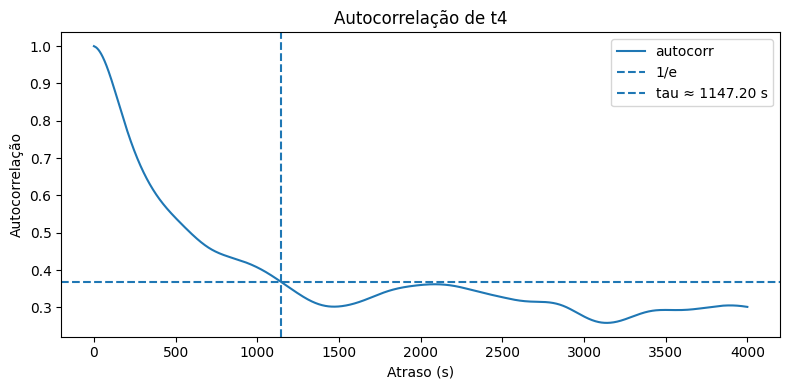

In [ ]:

def autocorr(x, maxlags=None):
    x = x - np.mean(x)
    n = len(x)
    if maxlags is None:
        maxlags = n - 1
    r = np.correlate(x, x, mode='full')[(n-1):(n-1)+maxlags+1]
    r = r / r[0]
    return r

r = autocorr(target, maxlags=min(5000, len(target)-1))
lags = np.arange(len(r)) * orig_dt
threshold = 1.0 / np.e
idx = np.where(r <= threshold)[0]
tau = float(lags[idx[0]] if idx.size > 0 else lags[-1])
print(f"Estimativa do tempo de autocorrelação (primeiro atraso onde autocorr <= 1/e): tau ≈ {tau:.2f} s")

plt.figure(figsize=(8,4))
plt.plot(lags, r, label='autocorr')
plt.axhline(threshold, linestyle='--', label='1/e')
plt.axvline(tau, linestyle='--', label=f'tau ≈ {tau:.2f} s')
plt.xlabel('Atraso (s)')
plt.ylabel('Autocorrelação')
plt.title('Autocorrelação de t4')
plt.legend()
plt.tight_layout()
plt.show()


Valores heurísticos:
  fs_tau (5 amostras por tau) = 0.004358 Hz
  fs_f95 (5x a frequência com 95% da energia) = 0.012207 Hz
  fator de decimação escolhido = 102
  novo intervalo de amostragem Ts_new = 81.60 s (fs_new = 0.012255 Hz)


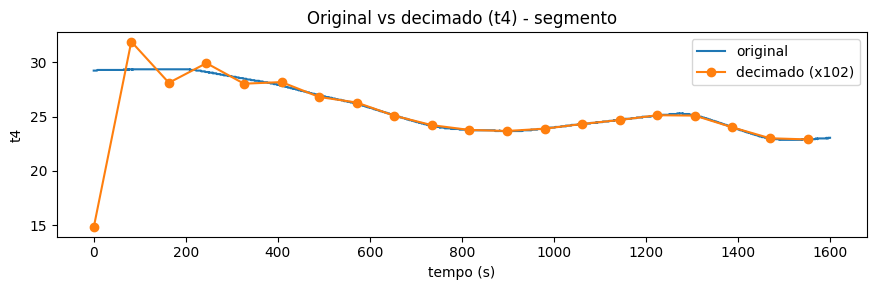

In [ ]:

# Heuristics used (conservative):
#  - Use characteristic time tau: sample at ~5 samples per tau => fs_tau = 5 / tau
#  - Use spectral content: sample at ~5x the frequency that contains 95% of energy => fs_f95 = 5 * f95
#  - Choose fs_new = min(orig_fs, max(fs_tau, fs_f95)) (do not increase sampling frequency)
#  - decimation = round(orig_fs / fs_new), enforce >=1

fs_tau = (5.0 / tau) if tau > 0 else orig_fs
fs_f95 = 5.0 * f95
fs_new_candidate = min(orig_fs, max(fs_tau, fs_f95))

decimation = int(round(orig_fs / fs_new_candidate))
decimation = max(1, decimation)
Ts_new = orig_dt * decimation
fs_new = orig_fs / decimation

print("Valores heurísticos:")
print(f"  fs_tau (5 amostras por tau) = {fs_tau:.6f} Hz")
print(f"  fs_f95 (5x a frequência com 95% da energia) = {fs_f95:.6f} Hz")
print(f"  fator de decimação escolhido = {decimation}")
print(f"  novo intervalo de amostragem Ts_new = {Ts_new:.2f} s (fs_new = {fs_new:.6f} Hz)")

# show a small visual comparison (portion) if decimation > 1
if decimation > 1:
    segment_length = 2000
    t_dec = decimate(df["t4"].to_numpy(), decimation, ftype='fir', zero_phase=True)
    t_dec_time = np.arange(len(t_dec)) * Ts_new
    plt.figure(figsize=(9,3))
    plt.plot(np.arange(segment_length) * orig_dt, df["t4"].to_numpy()[:segment_length], label='original')
    plt.plot(t_dec_time[:int(np.ceil(segment_length/decimation))], t_dec[:int(np.ceil(segment_length/decimation))], 'o-', label=f'decimado (x{decimation})')
    plt.xlabel("tempo (s)")
    plt.ylabel("t4")
    plt.legend()
    plt.title("Original vs decimado (t4) - segmento")
    plt.tight_layout()
    plt.show()


In [ ]:

candidates = ["u", "t0", "t1", "t2", "t3"]
target_name = "t4"

# Pearson correlation with target
corrs = df[candidates].corrwith(df[target_name]).abs().sort_values(ascending=False)
print("Correlação dos candidatos com t4 (em ordem decrescente pelo valor absoluto):")
print(corrs)

# Pairwise correlation matrix among candidates
pairwise_corr = df[candidates].corr() #type: ignore
print("\nCorrelação entre pares dos candidatos:")
display(pairwise_corr)

# VIF calculation
X = df[candidates].astype(float)
vif = pd.DataFrame({
    "variable": X.columns,
    "VIF": [variance_inflation_factor(X.to_numpy(), i) for i in range(X.shape[1])]
}).sort_values("VIF", ascending=False)
print("\nFatores de Inflação da Variância (VIF) para os candidatos:")
display(vif)

# Greedy selection to keep multicollinearity manageable:
selected = []
for var in corrs.index:
    trial = selected + [var]
    X_trial = df[trial].astype(float)
    # compute VIFs for trial set
    if len(trial) == 1:
        # Single variable always has VIF = 1, add it automatically
        selected.append(var)
    else:
        vif_trial = [variance_inflation_factor(X_trial.to_numpy(), i) for i in range(X_trial.shape[1])]
        if len(vif_trial) > 0 and max(vif_trial) < 10:
            selected.append(var)

print("\nConjunto selecionado (mantém FIV < 10):", selected)

# Performance baseline: R^2 of linear model with selected vars
if selected:
    Xsel = df[selected].to_numpy()
    y = df[target_name].to_numpy()
    r2 = LinearRegression().fit(Xsel, y).score(Xsel, y)
    print(f"R^2 linear usando o conjunto selecionado {selected}: {r2:.4f}")
else:
    print("Nenhuma variável passou no limite de FIV na seleção gananciosa.")


Correlação dos candidatos com t4 (em ordem decrescente pelo valor absoluto):
t2   0.9636
t1   0.9494
u    0.1506
t3   0.1384
t0   0.0565
dtype: float64

Correlação entre pares dos candidatos:


,u,t0,t1,t2,t3
u,1.0000,0.5532,-0.3881,-0.3402,0.4799
t0,0.5532,1.0000,-0.1816,-0.1505,0.9918
t1,-0.3881,-0.1816,1.0000,0.9983,-0.0818
t2,-0.3402,-0.1505,0.9983,1.0000,-0.0537
t3,0.4799,0.9918,-0.0818,-0.0537,1.0000



Fatores de Inflação da Variância (VIF) para os candidatos:


,variable,VIF
2,t1,241702.0743
3,t2,230636.1775
4,t3,77517.8626
1,t0,67513.3945
0,u,19.9048



Conjunto selecionado (mantém FIV < 10): ['t2', 'u']
R^2 linear usando o conjunto selecionado ['t2', 'u']: 0.9641


In [ ]:

from sklearn.metrics import mean_squared_error
from itertools import product
import warnings
warnings.filterwarnings("ignore")

# Given results from previous step:
decimation = 102
Ts_new = 81.60
orig_dt = 0.8
orig_fs = 1.0 / orig_dt

# Columns and target
candidates = ["u", "t0", "t1", "t2", "t3"]
target_col = "t4"

# Decimate all signals by integer factor (zero-phase FIR filtering via scipy.signal.decimate)
dec_df = pd.DataFrame({
    col: decimate(df[col].to_numpy(), decimation, ftype='fir', zero_phase=True)
    for col in ["u","t0","t1","t2","t3","t4"]
})

dec_df.reset_index(drop=True, inplace=True)
dec_df.index.name = "amostra"
print(f"Dataset decimado: {dec_df.shape[0]} amostras, Ts_novo = {Ts_new} s (decimação = {decimation})")
display(dec_df.head())


Dataset decimado: 835 amostras, Ts_novo = 81.6 s (decimação = 102)


,u,t0,t1,t2,t3,t4
amostra,,,,,,
0,0.1863,13.8838,14.7589,14.7824,13.9519,14.7993
1,-0.3770,30.0286,31.7590,31.8016,30.0986,31.9203
2,1.5474,26.2882,27.9653,28.0020,26.3743,28.1277
3,5.0465,29.5930,29.1002,29.3016,29.3154,29.9366
4,4.9944,29.4972,26.9035,27.1644,29.0215,28.0437


In [ ]:

seed = 0
np.random.seed(seed)

N = len(dec_df)
idx = np.arange(N)
np.random.shuffle(idx)

n_test = int(np.floor(0.15 * N))
n_val  = int(np.floor(0.25 * N))
n_train = N - n_val - n_test

# assign
test_idx = idx[:n_test]
val_idx  = idx[n_test:n_test+n_val]
train_idx = idx[n_test+n_val:]

train_df = dec_df.iloc[train_idx].reset_index(drop=True)
val_df   = dec_df.iloc[val_idx].reset_index(drop=True)
test_df  = dec_df.iloc[test_idx].reset_index(drop=True)

print(f"Tamanhos dos conjuntos: treinamento={len(train_df)}, validação={len(val_df)}, teste={len(test_df)}")


Tamanhos dos conjuntos: treinamento=502, validação=208, teste=125


In [ ]:

# We will use the convention: y(k) predicted by y(k-1..k-na), u(k-1..k-nb_u), t2(k-1..k-nb_t2)
def build_regressors(df_in, target_col="t4", na=1, nb_u=1, nb_t2=1, nk=1):
    """
    Build regressors X and target y aligned so that y[k] corresponds to:
      y[k] = f( y[k-1..k-na], u[k-nk..k-nk-nb_u+1], t2[...] )
    nk: input delay (commonly 1)
    Returns (X, y) where rows with NaN (due to lagging) are dropped.
    """
    df = df_in.copy().reset_index(drop=True)
    N = len(df)
    rows = []
    for k in range(N):
        # need indices up to k for regressors: earliest index = k - max_lag
        maxlag = max(na, nk + nb_u - 1, nk + nb_t2 - 1)
        if k - maxlag < 0:
            rows.append(None)
            continue
        vec = []
        # past outputs y(k-1..k-na)
        for j in range(1, na+1):
            vec.append(df.loc[k-j, target_col])
        # input u delays u(k-nk .. k-nk-nb_u+1)
        for j in range(nk, nk+nb_u):
            vec.append(df.loc[k-j, "u"])
        # t2 delays
        for j in range(nk, nk+nb_t2):
            vec.append(df.loc[k-j, "t2"])
        rows.append(vec)
    # collect valid rows
    valid_idx = [i for i,r in enumerate(rows) if r is not None]
    X = np.array([rows[i] for i in valid_idx])
    y = df.loc[valid_idx, target_col].to_numpy()
    return X, y, valid_idx


In [ ]:

# We will search na in 1..6, nb_u in 1..6, nb_t2 in 1..6, nk fixed to 1.
# The model is linear (least-squares), no noise model (ARX).
na_range = range(1,7)
nb_range = range(1,7)
nk = 1

best_arx = {"mse": np.inf, "na": None, "nb_u": None, "nb_t2": None, "reg": None}
for na, nb_u, nb_t2 in product(na_range, nb_range, nb_range):
    # Build regressors using train set for estimation, evaluate on test set
    X_train, y_train, valid_train_idx = build_regressors(train_df, na=na, nb_u=nb_u, nb_t2=nb_t2, nk=nk)
    X_test, y_test, valid_test_idx = build_regressors(test_df, na=na, nb_u=nb_u, nb_t2=nb_t2, nk=nk)
    # Need min rows > 0
    if X_train.shape[0] < 10 or X_test.shape[0] < 5:
        continue

    # ensure pure numeric numpy arrays for sklearn
    reg = LinearRegression().fit(X_train.astype(float), y_train.astype(float))
    y_pred = reg.predict(X_test.astype(float))
    mse = mean_squared_error(y_test.astype(float), y_pred)
    if mse < best_arx["mse"]:
        best_arx = {"na": na, "nb_u": nb_u, "nb_t2": nb_t2, "mse": mse, "reg": reg}

print("Melhor estrutura ARX (segundo MSE no teste):")
print(f"  na = {best_arx['na']}, nb_u = {best_arx['nb_u']}, nb_t2 = {best_arx['nb_t2']}, MSE de teste = {best_arx['mse']:.6f}")

Melhor estrutura ARX (segundo MSE no teste):
  na = 1, nb_u = 6, nb_t2 = 1, MSE de teste = 4.501488


In [ ]:

# We'll reuse the ARX lag grid but create polynomial features: linear + pairwise interactions + squared terms (degree up to 2).
from sklearn.preprocessing import PolynomialFeatures

best_poly = {"mse": np.inf, "na": None, "nb_u": None, "nb_t2": None, "poly": None, "reg": None}
degrees = [2]  # degree 2 is usually sufficient for mild nonlinearity; if desired add 3
for na, nb_u, nb_t2 in product(na_range, nb_range, nb_range):
    Xtr, ytr, _ = build_regressors(train_df, na=na, nb_u=nb_u, nb_t2=nb_t2, nk=nk)
    Xte, yte, _ = build_regressors(test_df, na=na, nb_u=nb_u, nb_t2=nb_t2, nk=nk)
    if Xtr.shape[0] < 20 or Xte.shape[0] < 5:
        continue
    # polynomial expansion degree=2 (include interaction and squared)
    poly = PolynomialFeatures(degree=2, include_bias=False)
    Xtr_p = poly.fit_transform(Xtr)
    Xte_p = poly.transform(Xte)
    # if dimensionality is too large relative to samples, skip (to avoid ill-conditioning)
    if Xtr_p.shape[1] > Xtr.shape[0]//2:
        # skip overly large feature expansions
        continue
    assert type(Xte_p) is np.ndarray
    reg = LinearRegression().fit(Xtr_p.astype(float), ytr.astype(float))
    ypred = reg.predict(Xte_p.astype(float))
    mse = mean_squared_error(yte.astype(float), ypred)
    if mse < best_poly["mse"]:
        best_poly = {"na": na, "nb_u": nb_u, "nb_t2": nb_t2, "mse": mse, "poly": poly, "reg": reg, "nfeat": Xtr_p.shape[1]}

print("Melhor estrutura NARX (degree=2) (segundo MSE no teste):")
print(f"  na = {best_poly['na']}, nb_u = {best_poly['nb_u']}, nb_t2 = {best_poly['nb_t2']}, MSE de teste = {best_poly['mse']:.6f}, n_atributos = {best_poly.get('nfeat',None)}")

Melhor estrutura NARX (degree=2) (segundo MSE no teste):
  na = 1, nb_u = 3, nb_t2 = 1, MSE de teste = 4.599564, n_atributos = 20


In [ ]:

# Approach:
#  - choose regressors (lags) similarly
#  - cluster regressor space (fuzzy c-means) with n_rules between 2 and 5
#  - identify local linear models with weighted least squares using membership degrees from clustering
#  - evaluate TEST MSE and select best (na, nb_u, nb_t2, n_rules)
#

from skfuzzy import cluster

def fuzzy_TS_fit_predict(X_train, y_train, X_test, n_rules, maxiter=150, m=2.0):
    """
    Given X_train, y_train, do fuzzy c-means clustering on X_train to obtain soft memberships,
    then compute local linear models via weighted least squares using membership degrees as weights.
    Return predictions on X_test.
    """
    # transpose for skfuzzy interface: data shape (features, samples)
    cntr, u, u0, d, jm, p, fpc = cluster.cmeans(
        X_train.T, c=n_rules, m=m, error=1e-5, maxiter=maxiter, init=None)
    # u shape: (n_rules, n_samples)
    memberships_train = u.T  # (n_samples, n_rules)
    # For test points, compute distances to centroids and convert to memberships via same formula
    # skfuzzy provides cmeans_predict
    u_test, u0_test, d_test, jm_test, p_test, fpc_test = cluster.cmeans_predict(
        X_test.T, cntr, m, error=1e-5, maxiter=maxiter)
    memberships_test = u_test.T

    # Build local linear models using weighted least squares
    n_rules_local = memberships_train.shape[1]
    coefs = []
    intercepts = []
    for r in range(n_rules_local):
        w = memberships_train[:, r]
        # Weighted least squares: solve for beta in min ||W^(1/2)(Xb - y)||^2
        W = np.sqrt(w)[:, None]  # (n_samples,1)
        Xw = X_train * W
        yw = y_train * W.ravel()
        # Add bias term
        Xw_aug = np.hstack([np.ones((Xw.shape[0],1)), Xw])
        # Regularize lightly to avoid singularities
        lam = 1e-6
        A = Xw_aug.T @ Xw_aug + lam * np.eye(Xw_aug.shape[1])
        b = Xw_aug.T @ yw
        theta = np.linalg.solve(A, b)
        intercepts.append(theta[0])
        coefs.append(theta[1:])
    coefs = np.array(coefs)      # shape (n_rules, n_features)
    intercepts = np.array(intercepts)
    # Predict on X_test: weighted sum of local outputs using memberships_test
    y_local = (intercepts[None, :] + X_test @ coefs.T)  # (n_test, n_rules)
    y_pred = np.sum(memberships_test * y_local, axis=1)
    return y_pred

best_fuzzy = {"mse": np.inf, "na": None, "nb_u": None, "nb_t2": None, "n_rules": None}
n_rules_options = [2,3,4,5]
# limit lag grid to reasonable sizes to keep computation time reasonable
na_range_f = range(1,5)
nb_range_f = range(1,5)

for na, nb_u, nb_t2 in product(na_range_f, nb_range_f, nb_range_f):
    Xtr, ytr, _ = build_regressors(train_df, na=na, nb_u=nb_u, nb_t2=nb_t2, nk=1)
    Xte, yte, _ = build_regressors(test_df, na=na, nb_u=nb_u, nb_t2=nb_t2, nk=1)
    if Xtr.shape[0] < 30 or Xte.shape[0] < 8:
        continue
    for n_rules in n_rules_options:
        try:
            ypred = fuzzy_TS_fit_predict(Xtr, ytr, Xte, n_rules=n_rules)
            mse = mean_squared_error(yte.astype(float), ypred)
            if mse < best_fuzzy["mse"]:
                best_fuzzy = {"na":na, "nb_u":nb_u, "nb_t2":nb_t2, "n_rules":n_rules, "mse":mse}
        except Exception:
            continue

print("Melhor Takagi-Sugeno fuzzy NARX (segundo MSE no teste):")
print(f"  na={best_fuzzy.get('na')}, nb_u={best_fuzzy.get('nb_u')}, nb_t2={best_fuzzy.get('nb_t2')}, n_regras={best_fuzzy.get('n_rules')}, MSE de teste={best_fuzzy.get('mse'):.6f}")

Melhor Takagi-Sugeno fuzzy NARX (segundo MSE no teste):
  na=2, nb_u=1, nb_t2=2, n_regras=5, MSE de teste=5.763859


Estruturas dos modelos selecionados (baseado na busca no conjunto de TESTE):
1) ARX: na=1, nb_u=6, nb_t2=1, MSE=4.501488
2) NARX polinomial (degree=2): na=1, nb_u=3, nb_t2=1, MSE=4.599564
3) Takagi-Sugeno fuzzy NARX: na=2, nb_u=1, nb_t2=2, n_regras=5, MSE=5.763859


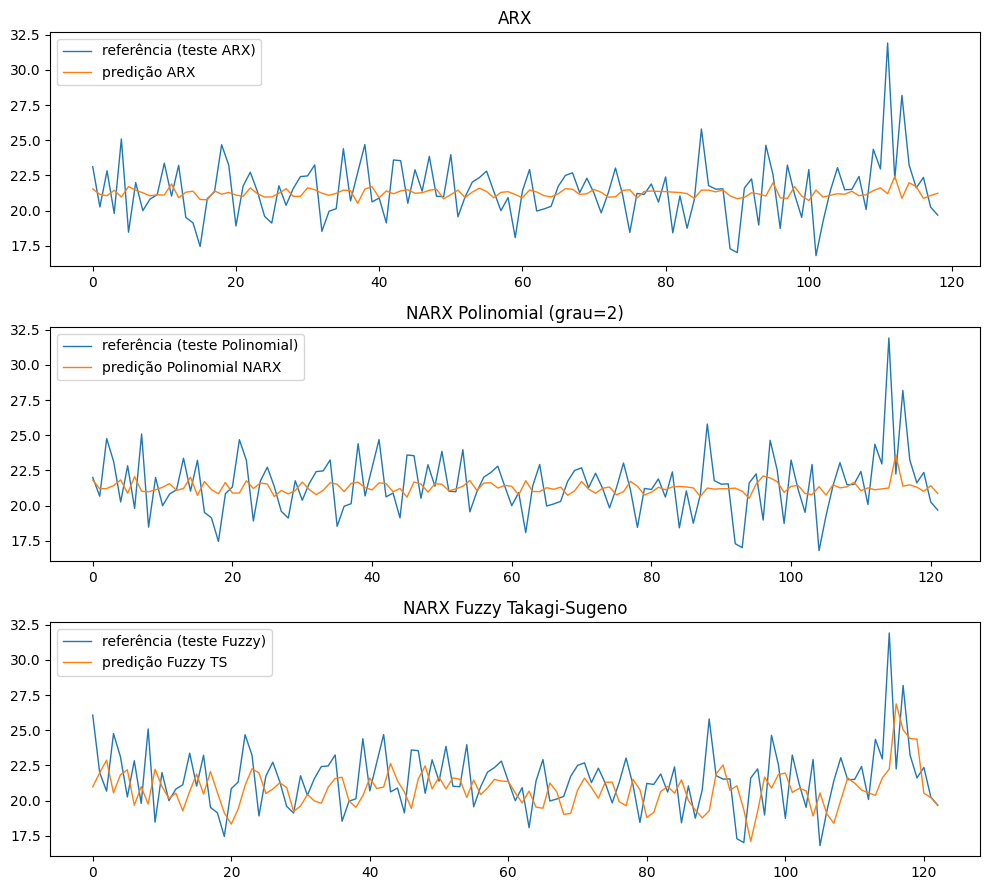

In [ ]:

print("Estruturas dos modelos selecionados (baseado na busca no conjunto de TESTE):")
print(f"1) ARX: na={best_arx['na']}, nb_u={best_arx['nb_u']}, nb_t2={best_arx['nb_t2']}, MSE={best_arx['mse']:.6f}")
print(f"2) NARX polinomial (degree=2): na={best_poly['na']}, nb_u={best_poly['nb_u']}, nb_t2={best_poly['nb_t2']}, MSE={best_poly['mse']:.6f}")
print(f"3) Takagi-Sugeno fuzzy NARX: na={best_fuzzy.get('na')}, nb_u={best_fuzzy.get('nb_u')}, nb_t2={best_fuzzy.get('nb_t2')}, n_regras={best_fuzzy.get('n_rules')}, MSE={best_fuzzy.get('mse'):.6f}")

# prepare test true y (ensure integer lag orders)
na_max = max(int(best_arx['na']), int(best_poly['na']), int(best_fuzzy.get('na') or 1))
nb_u_max = max(int(best_arx['nb_u']), int(best_poly['nb_u']), int(best_fuzzy.get('nb_u') or 1))
nb_t2_max = max(int(best_arx['nb_t2']), int(best_poly['nb_t2']), int(best_fuzzy.get('nb_t2') or 1))
_, y_test_all, _ = build_regressors(test_df, na=int(na_max), nb_u=int(nb_u_max), nb_t2=int(nb_t2_max), nk=1)

# Recompute predictions aligned to the above (choose each model's own lags to get correct predictions)
# ARX prediction
Xtr_arx, ytr_arx, _ = build_regressors(train_df, na=int(best_arx['na']), nb_u=int(best_arx['nb_u']), nb_t2=int(best_arx['nb_t2']), nk=1)
Xte_arx, yte_arx, _ = build_regressors(test_df, na=int(best_arx['na']), nb_u=int(best_arx['nb_u']), nb_t2=int(best_arx['nb_t2']), nk=1)

# Ensure we have a valid regressor; if not, refit using saved orders
reg_arx = best_arx.get('reg', None)
if reg_arx is None or not hasattr(reg_arx, 'predict'):
    reg_arx = LinearRegression().fit(Xtr_arx.astype(float), ytr_arx.astype(float))
    best_arx['reg'] = reg_arx
yhat_arx = reg_arx.predict(Xte_arx.astype(float))

# Poly prediction
Xtr_p, ytr_p, _ = build_regressors(train_df, na=int(best_poly['na']), nb_u=int(best_poly['nb_u']), nb_t2=int(best_poly['nb_t2']), nk=1)
Xte_p, yte_p, _ = build_regressors(test_df, na=int(best_poly['na']), nb_u=int(best_poly['nb_u']), nb_t2=int(best_poly['nb_t2']), nk=1)

# Ensure polynomial transformer and regressor exist; if not, rebuild them
poly = best_poly.get('poly', None)
reg_poly = best_poly.get('reg', None)
if poly is None or not hasattr(poly, 'transform'):
    from sklearn.preprocessing import PolynomialFeatures
    poly = PolynomialFeatures(degree=2, include_bias=False)
    Xtr_p_trans = poly.fit_transform(Xtr_p.astype(float))
    reg_poly = LinearRegression().fit(Xtr_p_trans.astype(float), ytr_p.astype(float))
    best_poly['poly'] = poly
    best_poly['reg'] = reg_poly
    Xte_p_trans = poly.transform(Xte_p.astype(float))
else:
    Xte_p_trans = poly.transform(Xte_p.astype(float))
    if reg_poly is None or not hasattr(reg_poly, 'predict'):
        Xtr_p_trans = poly.fit_transform(Xtr_p.astype(float))
        reg_poly = LinearRegression().fit(Xtr_p_trans.astype(float), ytr_p.astype(float))
        best_poly['reg'] = reg_poly

assert type(Xte_p_trans) is np.ndarray
yhat_poly = reg_poly.predict(Xte_p_trans.astype(float))

# Fuzzy prediction (recompute with saved best settings)
Xtr_f, ytr_f, _ = build_regressors(train_df, na=int(best_fuzzy['na']), nb_u=int(best_fuzzy['nb_u']), nb_t2=int(best_fuzzy['nb_t2']), nk=1)
Xte_f, yte_f, _ = build_regressors(test_df, na=int(best_fuzzy['na']), nb_u=int(best_fuzzy['nb_u']), nb_t2=int(best_fuzzy['nb_t2']), nk=1)
# Use the same function implemented above to predict (it will perform clustering on Xtr_f)
yhat_fuzzy = None
yhat_fuzzy = []

# For speed we use the same function used in selection, but we perform a single fit/predict here
if len(Xtr_f) > 0 and len(Xte_f) > 0:
    # reconstruct membership+fit using chosen n_rules
    yhat_fuzzy = (lambda Xtr=Xtr_f, ytr=ytr_f, Xte=Xte_f, n_rules=int(best_fuzzy['n_rules']): 
                    fuzzy_TS_fit_predict(Xtr, ytr, Xte, n_rules))
    yhat_fuzzy = yhat_fuzzy()

# Align yte arrays might be different lengths; we plot each model's predicted vs actual for its own test slice
fig, axs = plt.subplots(3,1, figsize=(10,9), sharex=False)
axs[0].plot(yte_arx, label='referência (teste ARX)', linewidth=1)
axs[0].plot(yhat_arx, label='predição ARX', linewidth=1)
axs[0].legend(); axs[0].set_title("ARX")

axs[1].plot(yte_p, label='referência (teste Polinomial)', linewidth=1)
axs[1].plot(yhat_poly, label='predição Polinomial NARX', linewidth=1)
axs[1].legend(); axs[1].set_title("NARX Polinomial (grau=2)")

axs[2].plot(yte_f, label='referência (teste Fuzzy)', linewidth=1)
axs[2].plot(yhat_fuzzy, label='predição Fuzzy TS', linewidth=1)
axs[2].legend(); axs[2].set_title("NARX Fuzzy Takagi-Sugeno")

plt.tight_layout()
plt.show()
